<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/MLOps/MLOps04/Vertex_AI_%EB%B9%85%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%A5%BC_%EC%9D%B4%EC%9A%A9%ED%95%9C_%EB%AA%A8%EB%8D%B8_%ED%95%99%EC%8A%B5_%EB%B0%8F_%EB%B0%B0%ED%8F%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

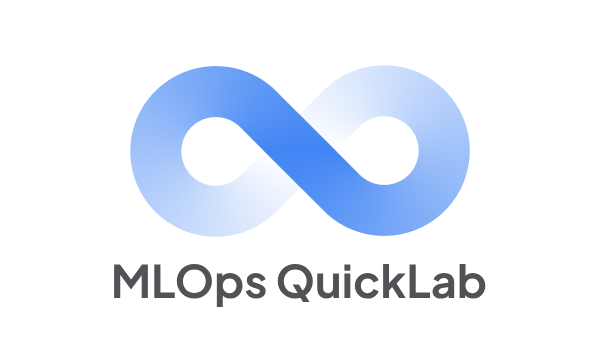

# 7. Vertex AI - 빅데이터를 이용한 모델 학습 및 배포

### 📍프로젝트 경로 설정

In [1]:
drive_path = 'Colab Notebooks/Aiffel/' # 평상시 작업하는 드라이브 폴더 경로를 입력해 주세요.
project_name = 'MLOpsProject'       # 이번 프로젝트세 사용하는 폴더명을 입력해주세요.

In [2]:
from google.colab import drive
from IPython.display import clear_output
import os
# 1. 구글 드라이브 마운트
print("[0;33mConnecting...")
drive.mount('/content/gdrive')
# 2. 경로 설정 및 폴더 생성
project_path = os.path.join('/content/gdrive/MyDrive',drive_path, project_name)
# Create the project directory if it doesn't exist
os.makedirs(project_path, exist_ok=True)
clear_output()
print(f"✅ Google Drive 연결 성공!! ( project_path: {project_path} )")

✅ Google Drive 연결 성공!! ( project_path: /content/gdrive/MyDrive/Colab Notebooks/Aiffel/MLOpsProject )


In [3]:
%cd "{project_path}"

/content/gdrive/MyDrive/Colab Notebooks/Aiffel/MLOpsProject


## 사전준비

### 필수 라이브러리 설치

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

In [ ]:
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

### Kaggle로 부터 데이터셋 준비
https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data 데이터셋 활용
위 데이터셋은 유저 `Cust_Id`의 영화 `Movie_Id` 시청에 따른 호응도 `Rating` 정보가 포함되어있음.

**데이터 형태**

Item | Description
-----|-------------
특징 | 시계열 데이터 (Time series)
전체 크기 | 100 ,480,507
영화 수 | 17,770

In [ ]:
!pip install kaggle
!kaggle datasets download -d netflix-inc/netflix-prize-data
!unzip "netflix-prize-data.zip" -d netflix-prize-data

Dataset URL: https://www.kaggle.com/datasets/netflix-inc/netflix-prize-data
License(s): other
100% 683M/683M [00:03<00:00, 204MB/s]

Archive:  netflix-prize-data.zip
  inflating: netflix-prize-data/README  
  inflating: netflix-prize-data/combined_data_1.txt  
  inflating: netflix-prize-data/combined_data_2.txt  
  inflating: netflix-prize-data/combined_data_3.txt  
  inflating: netflix-prize-data/combined_data_4.txt  
  inflating: netflix-prize-data/movie_titles.csv  
  inflating: netflix-prize-data/probe.txt  
  inflating: netflix-prize-data/qualifying.txt  


In [ ]:
!head netflix-prize-data/combined_data_1.txt

1:
1488844,3,2005-09-06
822109,5,2005-05-13
885013,4,2005-10-19
30878,4,2005-12-26
823519,3,2004-05-03
893988,3,2005-11-17
124105,4,2004-08-05
1248029,3,2004-04-22
1842128,4,2004-05-09


In [ ]:
!ls -alh netflix-prize-data | grep combined_data

-rw------- 1 root root 473M Nov 13  2019 combined_data_1.txt
-rw------- 1 root root 530M Nov 13  2019 combined_data_2.txt
-rw------- 1 root root 444M Nov 13  2019 combined_data_3.txt
-rw------- 1 root root 527M Nov 13  2019 combined_data_4.txt


## 데이터 전처리

1억개 전체 데이터로 학습을 돌리면, 매 Epoch당 약 6시간의 학습 시간이 요구되어
Epoch 당 약 10분의 학습 시간을 유도하기 위해 User 기준으로 `1 / 30` Ratio 비중으로 샘플링 수행.

In [ ]:
def load_netflix_data(data_dir: str) -> pd.DataFrame:
    files = [
        os.path.join(data_dir, f)
        for f in [
            "combined_data_1.txt",
            "combined_data_2.txt",
            "combined_data_3.txt",
            "combined_data_4.txt",
        ]
    ]
    data = pd.DataFrame()

    for file in files:
        df = pd.read_csv(file, header=None, names=["Cust_Id", "Rating", "Date"], usecols=[0, 1, 2])
        df["Rating"] = df["Rating"].astype(float)
        df["Movie_Id"] = (
            df["Cust_Id"]
            .apply(lambda x: x[:-1] if ":" in x else np.nan)
            .ffill()
            .astype(int)
        )
        df = df[df["Rating"].notna()]
        data = pd.concat([data, df])

    sample_fraction = 1 / 30.0
    sampled_users = random.sample(data["Cust_Id"].unique().tolist(),
                                    int(len(data["Cust_Id"].unique()) * sample_fraction))
    sampled_data = data[data["Cust_Id"].isin(sampled_users)]

    return sampled_data

## 모델 정의
모델은 `Rating`을 GT(Ground Truth) 데이터로 사용하여 예측하는 문제.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from typing import Tuple
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class NetflixDataset(Dataset):
    def __init__(self, data: pd.DataFrame, seq_len: int = 10):
        """
        data: Cust_Id, Movie_Id, Rating, Date 등의 열을 가진 DataFrame
        seq_len: 시퀀스 길이
        """
        self.seq_len = seq_len
        # 유저별 데이터 그룹핑 후 시퀀스 생성
        self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)

    def __len__(self) -> int:
        return len(self.data)

    def _create_sequences(self, user_data: pd.DataFrame) -> pd.DataFrame:
        # 날짜 기준으로 정렬
        user_data = user_data.sort_values(by="Date")

        # i:i+seq_len 윈도우로 Movie_Id, Rating을 시퀀스로 구성
        sequences = [
            (
                user_data["Movie_Id"].values[i:i+self.seq_len],
                user_data["Rating"].values[i:i+self.seq_len],
            )
            for i in range(len(user_data) - self.seq_len + 1)  # seq_len 길이를 만족하는 마지막 인덱스까지
        ]

        return pd.DataFrame(sequences, columns=["Movie_Sequence", "Rating_Sequence"])

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        movies = torch.tensor(self.data.iloc[idx]["Movie_Sequence"], dtype=torch.long)
        ratings = torch.tensor(self.data.iloc[idx]["Rating_Sequence"], dtype=torch.float)

        return movies, ratings

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

In [ ]:
# Load data
data_dir = "netflix-prize-data"
data = load_netflix_data(data_dir)

In [ ]:
# Process data
dataset = NetflixDataset(data)
data_loader = DataLoader(dataset, batch_size=512, shuffle=True)

/tmp/ipykernel_40480/3976683065.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.data = data.groupby("Cust_Id").apply(self._create_sequences).reset_index(drop=True)


In [ ]:
num_movies = data["Movie_Id"].max()
model = RecommendationNetwork(num_movies=num_movies, emb_size=100).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def calculate_accuracy(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    # 평점을 반올림하여 정확도 계산 (정수 평점 가정)
    y_pred_rounded = torch.round(y_pred)
    correct_predictions = (y_pred_rounded == y_true).float().sum()
    accuracy = correct_predictions / y_true.shape[0]
    return accuracy.item()

In [ ]:
loss_values: list[float] = []
accuracy_values: list[float] = []
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0
    count_batches = 0

    for movies, ratings in tqdm(data_loader):
        movies = movies.to(device)     # (batch_size, seq_len)
        ratings = ratings.to(device)   # (batch_size, seq_len)

        # 마지막 영화에 대한 평점 예측을 목표로 한다고 가정
        target = ratings[:, -1]  # 시퀀스의 마지막 평점을 타겟으로
        optimizer.zero_grad()
        outputs = model(movies)  # (batch_size,)

        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()

        accuracy = calculate_accuracy(outputs, target)
        total_loss += loss.item()
        total_accuracy += accuracy
        count_batches += 1

    avg_loss = total_loss / count_batches
    avg_accuracy = total_accuracy / count_batches
    loss_values.append(avg_loss)
    accuracy_values.append(avg_accuracy)
    print(f"Epoch {epoch+1}: Loss = {avg_loss}, Accuracy = {avg_accuracy}")

100%|██████████| 6294/6294 [05:20<00:00, 19.61it/s]


Epoch 1: Loss = 1.0749527332060747, Accuracy = 0.35956155814403273


100%|██████████| 6294/6294 [05:20<00:00, 19.67it/s]


Epoch 2: Loss = 1.0224756480286075, Accuracy = 0.37024281994763125


100%|██████████| 6294/6294 [05:20<00:00, 19.63it/s]


Epoch 3: Loss = 1.00135732657348, Accuracy = 0.37434904356873294


100%|██████████| 6294/6294 [05:27<00:00, 19.23it/s]


Epoch 4: Loss = 0.9860281002854862, Accuracy = 0.37748422511312596


100%|██████████| 6294/6294 [05:25<00:00, 19.35it/s]

Epoch 5: Loss = 0.9726146273966021, Accuracy = 0.3799195415895251


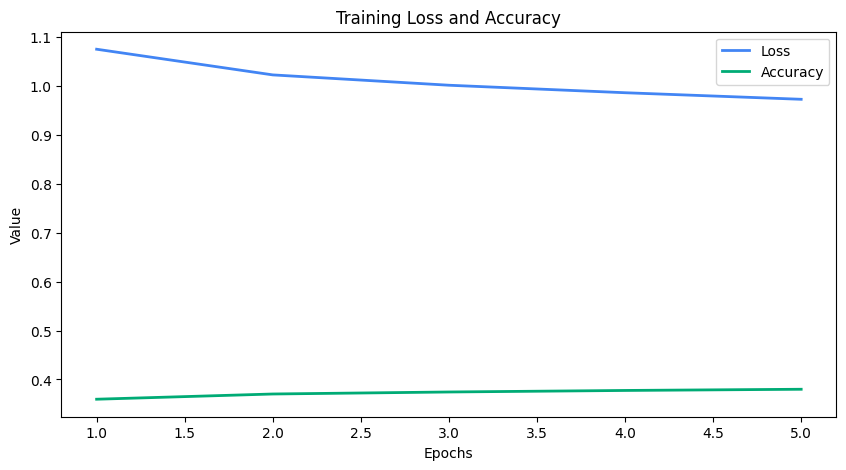

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), loss_values, label="Loss", color="#4285f4", linewidth=2)
plt.plot(range(1, num_epochs+1), accuracy_values, label="Accuracy", color="#00ab75", linewidth=2)
plt.title("Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.show()

## Inference

In [ ]:
%%writefile model.py
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, max_len: int = 5000):
        super(SinusoidalPositionalEncoding, self).__init__()
        # pos: [0 ... max_len-1]
        position = torch.arange(max_len).unsqueeze(1)
        # div_term: 각 차원별 주기를 달리하기 위한 분모
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))

        # pos_embedding: (max_len, emb_size)
        pos_embedding = torch.zeros(max_len, emb_size)
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        pos_embedding[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pos_embedding', pos_embedding)  # 학습 X, 등록된 텐서

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, emb_size)
        seq_len = x.size(1)
        # pos_embedding 중 seq_len 길이에 해당하는 부분만 사용
        return x + self.pos_embedding[:seq_len, :]

class RecommendationNetwork(nn.Module):
    def __init__(
        self,
        num_movies: int,
        emb_size: int = 100,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 512,
        max_seq_len: int = 5000  # 가변 시퀀스 길이 지원을 위해 충분히 큰 값 설정
    ):
        super(RecommendationNetwork, self).__init__()

        self.movie_emb = nn.Embedding(num_movies + 1, emb_size)
        self.pos_encoder = SinusoidalPositionalEncoding(emb_size, max_len=max_seq_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_size,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_size, 1)

    def forward(self, movies: torch.Tensor) -> torch.Tensor:
        """
        movies: (batch_size, seq_len)
        seq_len이 가변적이어도 positional encoding을 매번 해당 길이에 맞춰 계산 가능
        """
        batch_size, seq_len = movies.size()

        embedded = self.movie_emb(movies)  # (batch_size, seq_len, emb_size)
        pos_encoded = self.pos_encoder(embedded)  # (batch_size, seq_len, emb_size)

        transformer_out = self.transformer_encoder(pos_encoded)  # (batch_size, seq_len, emb_size)
        preds = self.fc(transformer_out[:, -1, :])  # (batch_size, 1)

        return preds.squeeze(1)  # (batch_size,)

Writing model.py


In [ ]:
%%writefile handler.py
import logging
from ts.torch_handler.base_handler import BaseHandler
import torch
from model import RecommendationNetwork

logging.basicConfig(level=logging.INFO)

class NetflixRecommendation(BaseHandler):
    def initialize(self, context):
        properties = context.system_properties
        model_dir = properties.get("model_dir")
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.num_movies = 17770
        # 가변 길이를 지원하는 모델이므로 seq_len을 고정하지 않습니다.
        self.model = RecommendationNetwork(num_movies=self.num_movies, emb_size=100)
        model_path = model_dir + "/model.pth"
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, data):
        """
        data 예: [[{"movies": [m1, ..., mN]}], [{"movies": [...]}, ...]]
        """
        logging.info("preprocess input: %s", data)

        # 요청 구조 기록
        self.batch_structure = [len(batch) for batch in data]

        sequences = []
        for batch in data:
            for row in batch:
                movie_seq = row["movies"]
                # 가변 길이 시퀀스를 지원하므로, 길이 검사를 제거합니다.
                sequences.append(movie_seq)

        # 패딩 필요 여부에 따라 처리할 수 있습니다.
        # Transformer에 바로 넣으려면 패딩과 마스크 처리 필요.
        # 여기서는 단순히 텐서 변환(가장 긴 시퀀스에 맞춰 패딩 필요)
        # 예: padding 처리
        max_len = max(len(seq) for seq in sequences)
        padded_sequences = [seq + [0]*(max_len - len(seq)) for seq in sequences]

        movies_tensor = torch.tensor(padded_sequences, dtype=torch.long, device=self.device)
        self.max_len = max_len  # postprocessing할 때는 필요없지만, inference에서 사용할 수 있음

        return movies_tensor

    def inference(self, data):
        """
        data: (total_batch_size, max_seq_len) 텐서 (패딩된 형태)
        """
        logging.info("inference data shape: %s", data.shape)
        with torch.no_grad():
            outputs = self.model(data)  # (total_batch_size,) 형태
        return outputs.tolist()

    def postprocess(self, inference_output):
        """
        inference_output: flat list of predictions
        """
        logging.info("postprocess output: %s", inference_output)

        final_output = []
        idx = 0
        for size in self.batch_structure:
            batch_preds = inference_output[idx:idx+size]
            idx += size
            final_output.append(batch_preds)
        return final_output

Writing handler.py


In [ ]:
torch.save(model.state_dict(), "model.pth")

In [ ]:
# 가상의 Context 클래스 정의 (TorchServe context 모사)
class Context:
    def __init__(self):
        self.system_properties = {
            "model_dir": "."
        }


context = Context()

In [ ]:
!pip install torchserve torch-model-archiver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 MB 62.8 MB/s eta 0:00:00


In [ ]:
from handler import NetflixRecommendation

# 핸들러 인스턴스화 및 초기화
netflix_recommendation = NetflixRecommendation()
netflix_recommendation.initialize(Context())

# 샘플 입력: seq_len=10 짜리 영화 시퀀스
sample_input = {"movies": [123, 456, 789, 100, 101, 102, 103, 104, 105, 106]}

# TorchServe 표준 입력 형태: [[sample_input]]
preprocessed = netflix_recommendation.preprocess([[sample_input]])
predicted_rating = netflix_recommendation.inference(preprocessed)
result = netflix_recommendation.postprocess(predicted_rating)

print(f"Predicted Rating: {result}")

Predicted Rating: [[4.210938453674316]]


## Register to Vertex AI

In [ ]:
!torch-model-archiver \
    --model-name model \
    --version 1.0 \
    --model-file model.py \
    --serialized-file model.pth \
    --handler handler.py \
    --export-path . \
    --force

In [ ]:
%%writefile config.properties
inference_address=http://0.0.0.0:9080
management_address=http://0.0.0.0:9081
metrics_address=http://0.0.0.0:9082
disable_system_metrics=true
number_of_netty_threads=32
job_queue_size=1000
model_store=/home/model-server/model-store

Writing config.properties


In [ ]:
# # for testing
# !torchserve \
#     --start \
#     --model-store ./ \
#     --models recommendation=model.mar \
#     --ts-config config.properties

# curl http://localhost:9080/ping

In [5]:
from google.cloud import storage, aiplatform
from google.oauth2 import service_account

In [ ]:
# from google.colab import auth
# auth.authenticate_user()

In [ ]:
# credentials = service_account.Credentials.from_service_account_file("credentials.json")

In [6]:
!gcloud auth application-default login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=ij2x6L6jHdqKgzbnOFznN4jLuCk0JR&prompt=consent&token_usage=remote&access_type=offline&code_challenge=JDbYsSNLbh_h6o8shzSg0YESJP10d3CoaFpDMtxEfHk&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0Aci98E8uhDa5SSLe_C9ZarNfYJZiSMbJN3fIG5tjHqQzT_E0l7aasxBgF2gTTTjJwE1ajw

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [7]:
!gcloud auth application-default set-quota-project mlops-study-493909


Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "mlops-study-493909" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [47]:
PROJECT_ID = "mlops-study-493909"                    # @param {type: "string"}
LOCATION = "asia-northeast3"                                       # @param {type: "string"}
BUCKET_NAME = "mlops-quicklab-1951"   # @param {type: "string"}
MODEL_FILE_NAME = "model.mar"              # @param {type: "string"}

In [48]:
# storage_client = storage.Client(credentials=credentials)
storage_client = storage.Client(project=PROJECT_ID)
bucket = storage_client.bucket(BUCKET_NAME)

In [49]:
def upload_blob(source_file_name: str, destination_blob_name: str) -> None:
    blob = bucket.blob(destination_blob_name)
    blob.upload_from_filename(source_file_name)
    print(f"File {source_file_name} uploaded to {destination_blob_name}.")

In [50]:
upload_blob("model.mar", f"models/{MODEL_FILE_NAME}")

File model.mar uploaded to models/model.mar.


### 런타임 재시작으로 체크해야 할 점



*   라이브러리 임포트 및 Colab 인증
*   환경 변수 재설정


### Vertex AI SDK 초기화

In [51]:
aiplatform.init(
    project=PROJECT_ID,
    location=LOCATION,
    # credentials=credentials,
)

### 모델 아티팩트 경로(GCS URI) 정의

In [12]:
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="Netflix Recommender",
    artifact_uri=model_path,
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/mlops-study-493909/mlops-quicklab/trainer:1.0.3",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A netflix rating classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

NotFound: 404 The image asia-northeast3-docker.pkg.dev/mlops-study-493909/mlops-quicklab/trainer:1.0.0 does not exist.



---


### 에러대응 부분

#### 인증 오류 해결.
- 코랩(Colab) 환경에서 auth.authenticate_user()를 실행했더라도, 터미널 명령어인 gcloud가 별도로 사용자 계정을 인식하지 못할 때 인증오류가 날 수 있음.
- 아래와 같은 간단한 코드로 별도 로그인 하여 해결

In [15]:
!gcloud auth login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=32555940559.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fappengine.admin+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcompute+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=pmSfRlHUr8AaPjmhX3BJS788c9Cnpp&prompt=consent&token_usage=remote&access_type=offline&code_challenge=oPT75LOKwMbQ-qogmywK-K6KmXTDmMvbTTD2tyu2rao&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0Aci98E_GdLqbA2zOcMGFq1L_rOQF3gMj6YfV7Lgh8LjjefnHxF3Hwi2dRH1Fpf4R5a-f3g

You are now logged in as [dalhangah@gmail.com].
Your current project is

In [28]:
%%writefile cloudbuild.yaml
steps:
- name: 'gcr.io/cloud-builders/docker'
  args: ['pull', 'asia-northeast3-docker.pkg.dev/sandbox-493404/mlops-quicklab/trainer:1.0.0']
- name: 'gcr.io/cloud-builders/docker'
  args: ['tag', 'asia-northeast3-docker.pkg.dev/sandbox-493404/mlops-quicklab/trainer:1.0.0', 'asia-northeast3-docker.pkg.dev/mlops-study-493909/mlops-quicklab/trainer:1.0.3']
images:
- 'asia-northeast3-docker.pkg.dev/mlops-study-493909/mlops-quicklab/trainer:1.0.3'

Overwriting cloudbuild.yaml


In [24]:
!gcloud config set project mlops-study-493909
!gcloud builds submit --no-source --config cloudbuild.yaml

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
ERROR: (gcloud.builds.submit) FAILED_PRECONDITION: invalid bucket "240586985884.cloudbuild-logs.googleusercontent.com"; service account 240586985884-compute@developer.gserviceaccount.com does not have access to the bucket


에러메시지에 나오는 '240586985884-compute@developer.gserviceaccount.com' 계정에게 권한을 준 후 다시 실행

In [25]:
!gcloud projects add-iam-policy-binding mlops-study-493909 \
    --member="serviceAccount:240586985884-compute@developer.gserviceaccount.com" \
    --role="roles/storage.admin"

Updated IAM policy for project [mlops-study-493909].
bindings:
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/aiplatform.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-nb.iam.gserviceaccount.com
  role: roles/aiplatform.colabServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform-vm.iam.gserviceaccount.com
  role: roles/aiplatform.notebookServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform.iam.gserviceaccount.com
  role: roles/aiplatform.serviceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/artifactregistry.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-artifactregistry.iam.gserviceaccount.com
  role: roles/artifactregistry.serviceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/bigquery.admin
- members:
  - serviceAcc

In [26]:
!gcloud projects add-iam-policy-binding mlops-study-493909 \
    --member="serviceAccount:240586985884@cloudbuild.gserviceaccount.com" \
    --role="roles/cloudbuild.builds.builder"

Updated IAM policy for project [mlops-study-493909].
bindings:
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/aiplatform.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-nb.iam.gserviceaccount.com
  role: roles/aiplatform.colabServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform-vm.iam.gserviceaccount.com
  role: roles/aiplatform.notebookServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform.iam.gserviceaccount.com
  role: roles/aiplatform.serviceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/artifactregistry.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-artifactregistry.iam.gserviceaccount.com
  role: roles/artifactregistry.serviceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/bigquery.admin
- members:
  - serviceAcc

In [29]:
!gcloud config set project mlops-study-493909
!gcloud builds submit --no-source --config cloudbuild.yaml

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
Created [https://cloudbuild.googleapis.com/v1/projects/mlops-study-493909/locations/global/builds/2e90fd79-fa0f-4ab7-8049-9589dc03dae3].
Logs are available at [ https://console.cloud.google.com/cloud-build/builds/2e90fd79-fa0f-4ab7-8049-9589dc03dae3?project=240586985884 ].
Waiting for build to complete. Polling interval: 1 second(s).
 REMOTE BUILD OUTPUT
starting build "2e90fd79-fa0f-4ab7-8049-9589dc03dae3"

FETCHSOURCE
BUILD
Starting Step #0
Step #0: Already have image (with digest): gcr.io/cloud-builders/docker
Step #0: Error response from daemon: Head "https://asia-northeast3-docker.pkg.dev/v2/sandbox-493404/mlops-quicklab/trainer/manifests/1.0.0": denied: Permission 'artifactregistry.repositories.downloadArtifacts' denied on resource (or it may not exist).
Finished Step #0
ERROR
ERROR: build step 0 "gcr.io/cloud-builders/docker" failed: step exited with non-zero status: 1


INFO: 

이번엔 240586985884-compute@developer.gserviceaccount.com 권한 부여

In [30]:
!gcloud projects add-iam-policy-binding sandbox-493404 \
    --member="serviceAccount:240586985884-compute@developer.gserviceaccount.com" \
    --role="roles/artifactregistry.reader"

Updated IAM policy for project [sandbox-493404].
bindings:
- members:
  - serviceAccount:github-actions-cicd@sandbox-493404.iam.gserviceaccount.com
  - serviceAccount:mlops-quicklab@sandbox-493404.iam.gserviceaccount.com
  role: roles/aiplatform.admin
- members:
  - serviceAccount:service-1024971204525@gcp-sa-vertex-nb.iam.gserviceaccount.com
  role: roles/aiplatform.colabServiceAgent
- members:
  - serviceAccount:service-1024971204525@gcp-sa-aiplatform-cc.iam.gserviceaccount.com
  role: roles/aiplatform.customCodeServiceAgent
- members:
  - serviceAccount:service-1024971204525@gcp-sa-aiplatform-vm.iam.gserviceaccount.com
  role: roles/aiplatform.notebookServiceAgent
- members:
  - serviceAccount:service-1024971204525@gcp-sa-aiplatform.iam.gserviceaccount.com
  role: roles/aiplatform.serviceAgent
- members:
  - serviceAccount:service-1024971204525@gcp-sa-vertex-telemetry.iam.gserviceaccount.com
  role: roles/aiplatform.telemetryServiceAgent
- members:
  - serviceAccount:github-actions-

In [31]:
!gcloud projects add-iam-policy-binding mlops-study-493909 \
    --member="serviceAccount:240586985884-compute@developer.gserviceaccount.com" \
    --role="roles/logging.logWriter"

Updated IAM policy for project [mlops-study-493909].
bindings:
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/aiplatform.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-nb.iam.gserviceaccount.com
  role: roles/aiplatform.colabServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform-vm.iam.gserviceaccount.com
  role: roles/aiplatform.notebookServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform.iam.gserviceaccount.com
  role: roles/aiplatform.serviceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/artifactregistry.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-artifactregistry.iam.gserviceaccount.com
  role: roles/artifactregistry.serviceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/bigquery.admin
- members:
  - serviceAcc

In [32]:
!gcloud config set project mlops-study-493909
!gcloud builds submit --no-source --config cloudbuild.yaml

[environment: untagged] Read more to tag: g.co/cloud/project-env-tag.
Updated property [core/project].
API [cloudbuild.googleapis.com] not enabled on project [mlops-study-493909]. 
Would you like to enable and retry (this will take a few minutes)? (y/N)?  y

Enabling service [cloudbuild.googleapis.com] on project [mlops-study-493909]...
Created [https://cloudbuild.googleapis.com/v1/projects/mlops-study-493909/locations/global/builds/55f13284-90fb-4033-93de-924e969f7e8d].
Logs are available at [ https://console.cloud.google.com/cloud-build/builds/55f13284-90fb-4033-93de-924e969f7e8d?project=240586985884 ].
Waiting for build to complete. Polling interval: 1 second(s).
 REMOTE BUILD OUTPUT
starting build "55f13284-90fb-4033-93de-924e969f7e8d"

FETCHSOURCE
BUILD
Starting Step #0
Step #0: Already have image (with digest): gcr.io/cloud-builders/docker
Step #0: 1.0.0: Pulling from sandbox-493404/mlops-quicklab/trainer
Step #0: 56e0351b9876: Pulling fs layer
Step #0: b0f696c0aebb: Pulling fs l

In [36]:
!gcloud projects add-iam-policy-binding mlops-study-493909 \
    --member="serviceAccount:240586985884-compute@developer.gserviceaccount.com" \
    --role="roles/artifactregistry.writer"

Updated IAM policy for project [mlops-study-493909].
bindings:
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/aiplatform.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-nb.iam.gserviceaccount.com
  role: roles/aiplatform.colabServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform-vm.iam.gserviceaccount.com
  role: roles/aiplatform.notebookServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform.iam.gserviceaccount.com
  role: roles/aiplatform.serviceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-telemetry.iam.gserviceaccount.com
  role: roles/aiplatform.telemetryServiceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/artifactregistry.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-artifactregistry.iam.gserviceaccount.com
  role: roles/artifactregistry.serviceAg

In [37]:
!gcloud projects add-iam-policy-binding mlops-study-493909 \
    --member="serviceAccount:240586985884@cloudbuild.gserviceaccount.com" \
    --role="roles/cloudbuild.builds.builder"

Updated IAM policy for project [mlops-study-493909].
bindings:
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/aiplatform.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-nb.iam.gserviceaccount.com
  role: roles/aiplatform.colabServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform-vm.iam.gserviceaccount.com
  role: roles/aiplatform.notebookServiceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-aiplatform.iam.gserviceaccount.com
  role: roles/aiplatform.serviceAgent
- members:
  - serviceAccount:service-240586985884@gcp-sa-vertex-telemetry.iam.gserviceaccount.com
  role: roles/aiplatform.telemetryServiceAgent
- members:
  - serviceAccount:mlops-quicklab@mlops-study-493909.iam.gserviceaccount.com
  role: roles/artifactregistry.admin
- members:
  - serviceAccount:service-240586985884@gcp-sa-artifactregistry.iam.gserviceaccount.com
  role: roles/artifactregistry.serviceAg

복제명령어 다시 해보기

In [38]:
!gcloud builds submit --no-source --config cloudbuild.yaml

Created [https://cloudbuild.googleapis.com/v1/projects/mlops-study-493909/locations/global/builds/46e7c9c6-48e8-4002-bec6-ccb200aa962e].
Logs are available at [ https://console.cloud.google.com/cloud-build/builds/46e7c9c6-48e8-4002-bec6-ccb200aa962e?project=240586985884 ].
Waiting for build to complete. Polling interval: 1 second(s).
 REMOTE BUILD OUTPUT
starting build "46e7c9c6-48e8-4002-bec6-ccb200aa962e"

FETCHSOURCE
BUILD
Starting Step #0
Step #0: Already have image (with digest): gcr.io/cloud-builders/docker
Step #0: 1.0.0: Pulling from sandbox-493404/mlops-quicklab/trainer
Step #0: 56e0351b9876: Pulling fs layer
Step #0: b0f696c0aebb: Pulling fs layer
Step #0: e627444df06f: Pulling fs layer
Step #0: dcf21018e934: Pulling fs layer
Step #0: a2855a2ef2e0: Pulling fs layer
Step #0: f7ce58fd6c11: Pulling fs layer
Step #0: 2d0884c1c557: Pulling fs layer
Step #0: 2671d90a6ae5: Pulling fs layer
Step #0: 035ca65cc946: Pulling fs layer
Step #0: 9290e1ba1d0d: Pulling fs layer
Step #0: 47058



---


### 아까 실패한데 부터 다시

In [52]:
model_path = f"gs://{BUCKET_NAME}/models"
registry_model = aiplatform.Model.upload(
    display_name="Netflix Recommender",
    artifact_uri=model_path,
    serving_container_image_uri="asia-northeast3-docker.pkg.dev/mlops-study-493909/mlops-quicklab/trainer:1.0.3",
    is_default_version=True,
    version_aliases=["v1"],
    version_description="A netflix rating classification model",
    serving_container_predict_route="/predictions/model",
    serving_container_health_route="/ping",
)

In [53]:
DEPLOY_COMPUTE = "n1-standard-2"
DEPLOY_ACCELERATOR = "NVIDIA_TESLA_T4"

In [54]:
endpoint = aiplatform.Endpoint.create(
    display_name="netflix-recommendation",
    project=PROJECT_ID,
    location=LOCATION,
)

In [57]:
deployment = registry_model.deploy(
    endpoint=endpoint,
    machine_type=DEPLOY_COMPUTE,
    min_replica_count=1,
    max_replica_count=1,
    accelerator_type=DEPLOY_ACCELERATOR,
    accelerator_count=1,
    traffic_percentage=100,
    sync=True,
)

ResourceExhausted: 429 The following quotas are exceeded: CustomModelServingT4GPUsPerProjectPerRegion 8: The following quotas are exceeded: CustomModelServingT4GPUsPerProjectPerRegion

In [59]:
instances = [{"movies": [100, 101, 102, 103, 104, 105, 106, 107, 108, 400]}]
endpoint.predict(instances=[instances])

Prediction(predictions=[[4.125799655914307]], deployed_model_id='736930076330819584', metadata=None, model_version_id='1', model_resource_name='projects/240586985884/locations/asia-northeast3/models/5413995255169024', explanations=None)

## Clean up

In [60]:
endpoint.undeploy_all()
endpoint.delete()

In [61]:
registry_model.delete()